Redshift failure rate for exposures with depth between 750s and 1250s

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
deep = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/LRG/alltiles_LRGzinfo.fits'))
print(len(deep), len(np.unique(deep['TARGETID'])))

mask = deep['subset']=='deep'
print(np.sum(mask))
mask &= deep['TARGETS']=='QSO+LRG'
print(np.sum(mask))

deep = deep[mask]
print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = deep['R_DEPTH_EBVAIR']>min_depth
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

print(len(deep), len(np.unique(deep['TARGETID'])))

deep.rename_columns(['B_DEPTH', 'R_DEPTH', 'Z_DEPTH', 'B_DEPTH_EBVAIR', 'R_DEPTH_EBVAIR', 'Z_DEPTH_EBVAIR'],
    ['B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep'])

79651 14100
14530
10113
10113 10113
FIBERSTATUS 8364 1749 0.1729457134381489
No data 8364 0 0.0
5942 2422 0.7104256336681014
5942 5942


__Add sweep columns__

In [4]:
# Snippets taken from desitarget

from desitarget.targets import encode_targetid

def decode_sweep_name(sweepname):
    sweepname = os.path.basename(sweepname)

    ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
    decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

    if sweepname[9] == 'm':
        decmin *= -1
    if sweepname[17] == 'm':
        decmax *= -1

    return [ramin, ramax, decmin, decmax]

def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

    ramin, ramax, decmin, decmax = radecbox

    # ADM check for some common mistakes.
    if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
        msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
        log.critical(msg)
        raise ValueError(msg)

    ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
          & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

    return ii

In [5]:
ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2']

# Ignore any possible north/south overlap (targetid automatically handles the north/south split)

sweep_fn_list = []
for field in ['north', 'south']:
    sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
    sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
sweep_fn_list = np.array(sweep_fn_list)

sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
mask = np.array([np.any(is_in_box(deep, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
print(np.sum(mask))
sweep_fn_list = sweep_fn_list[mask]

ls_stack = []
for sweep_fn in sweep_fn_list:
    ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
    targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
    idx = np.where(np.in1d(targetid, deep['TARGETID']))[0]
    if len(idx)==0:
        continue
    targetid = targetid[idx]
    ls = Table(fitsio.read(sweep_fn, rows=idx, columns=ls_columns))
    ls['TARGETID'] = targetid
    # pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
    # pz = Table(fitsio.read(pz_fn, rows=idx))
    # if '/south/sweep/' in sweep_fn:
    #     pz['field'] = 'south'
    # else:
    #     pz['field'] = 'north'
    # pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
    # ls = hstack([ls, pz])
    ls_stack.append(ls)
ls = vstack(ls_stack)
print(len(deep), len(ls))

# # This only works if the objects are unique
# _, idx1, idx2 = np.intersect1d(deep['TARGETID'], ls['TARGETID'], return_indices=True)
# print(len(deep), len(idx1), len(deep)-len(idx1))
# deep = deep[idx1]
# ls = ls[idx2]

deep = join(deep, ls, keys='TARGETID')

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    deep['gmag'] = 22.5 - 2.5*np.log10(deep['FLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rmag'] = 22.5 - 2.5*np.log10(deep['FLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zmag'] = 22.5 - 2.5*np.log10(deep['FLUX_Z']/deep['MW_TRANSMISSION_Z'])
    deep['w1mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W1']/deep['MW_TRANSMISSION_W1'])
    deep['w2mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W2']/deep['MW_TRANSMISSION_W2'])
    deep['gfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']/deep['MW_TRANSMISSION_Z'])

10
5942 5942


__Single exposure redshifts__

In [6]:
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/LRG/alltiles_LRGzinfo_1exp.fits'))
print(len(zbest), len(np.unique(zbest['TARGETID'])))

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
mask &= np.in1d(zbest['TILEID'], np.unique(deep['TILEID']))
zbest = zbest[mask]
print(len(zbest), len(np.unique(zbest['TARGETID'])))

mask = (zbest['FIBERSTATUS']==0) & (zbest['ZWARN'] & 2**9==0)
print(np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

zbest = join(zbest, deep[['TARGETID', 'B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep', 'gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'gfibermag', 'rfibermag', 'zfibermag']], keys='TARGETID')

198699 14100
80626 5942
76923 3703 0.045928112519534645


__Depth cut__

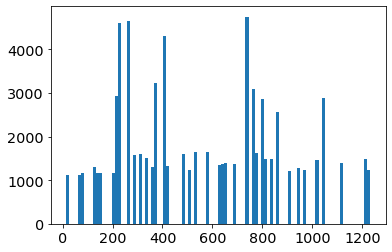

25298 0.3288743288743289


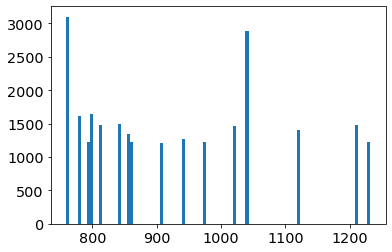

926.7776
862.9997


In [7]:
plt.hist(zbest['R_DEPTH_EBVAIR'], 100)
plt.show()

mask = (zbest['R_DEPTH_EBVAIR'] > 750) & (zbest['R_DEPTH_EBVAIR'] < 1250)
print(np.sum(mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

plt.hist(zbest['R_DEPTH_EBVAIR'], 100)
plt.show()

print(np.mean(zbest['R_DEPTH_EBVAIR']))
print(np.median(zbest['R_DEPTH_EBVAIR']))

In [8]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = zbest['SV1_DESI_TARGET'] & 2**0>0
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))

6686
6925
25298


In [9]:
print('Total # exposures in this analysis:', len(np.unique(zbest['EXPID'])))
t = Table()
t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
t['n_exp'] = 0
for index, tileid in enumerate(t['TILEID']):
    mask = zbest['TILEID']==tileid
    t['n_exp'][index] = len(np.unique(zbest['EXPID'][mask]))
t

Total # exposures in this analysis: 18


TILEID,count,n_exp
int32,int64,int64
80607,10187,7
80609,4902,3
80620,4078,3
80622,6131,5


--------

In [10]:
mask_zwarn = (zbest['ZWARN_deep']==0)

# Not repeatable
zdiff_threshold = 0.0033
mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also include objects with ZWARN!=0 in the deep coadds
mask_fail |= (~mask_zwarn)
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))

1735 0.0685824966400506
1787 0.07063799509842675


In [13]:
# Overall failure rates
print('LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(lrg_opt & mask_fail)/np.sum(lrg_opt)*100, np.sum(lrg_opt & mask_fail), np.sum(lrg_opt)))
print('LRG_IR:  {:.1f}% ({}/{})'.format(np.sum(lrg_ir & mask_fail)/np.sum(lrg_ir)*100, np.sum(lrg_ir & mask_fail), np.sum(lrg_ir)))
print('LRG_SV:  {:.1f}% ({}/{})'.format(np.sum(lrg_sv & mask_fail)/np.sum(lrg_sv)*100, np.sum(lrg_sv & mask_fail), np.sum(lrg_sv)))

LRG_OPT: 1.2% (82/6686)
LRG_IR:  2.1% (143/6925)
LRG_SV:  7.1% (1787/25298)


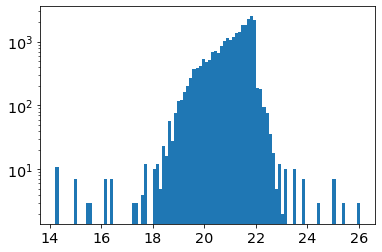

In [11]:
plt.hist(zbest['zfibermag'], 100, log=True);

In [20]:
bins = np.linspace(17.5, 23.2, 58)
print(bins)

[17.5 17.6 17.7 17.8 17.9 18.  18.1 18.2 18.3 18.4 18.5 18.6 18.7 18.8
 18.9 19.  19.1 19.2 19.3 19.4 19.5 19.6 19.7 19.8 19.9 20.  20.1 20.2
 20.3 20.4 20.5 20.6 20.7 20.8 20.9 21.  21.1 21.2 21.3 21.4 21.5 21.6
 21.7 21.8 21.9 22.  22.1 22.2 22.3 22.4 22.5 22.6 22.7 22.8 22.9 23.
 23.1 23.2]


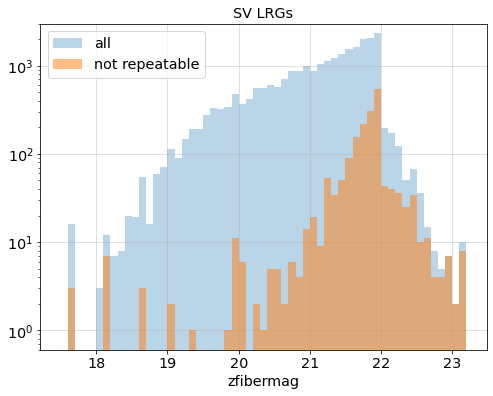

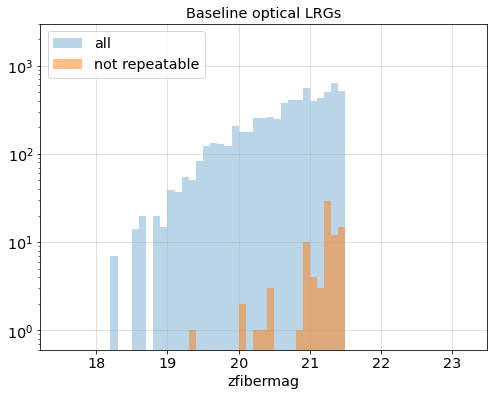

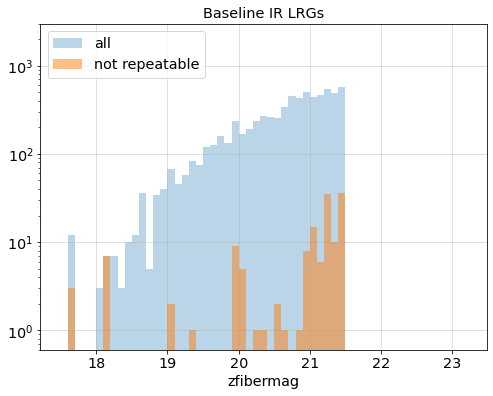

In [12]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['zfibermag'][lrg_sv], bins=bins, alpha=0.3, label='all', zorder=1, log=True)
plt.hist(zbest['zfibermag'][mask_fail & lrg_sv], bins=bins, alpha=0.5, label='not repeatable', zorder=2)
plt.xlabel('zfibermag')
plt.title('SV LRGs')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.ylim(0.6, 3e3)
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(zbest['zfibermag'][lrg_opt], bins=bins, alpha=0.3, label='all', zorder=1, log=True)
plt.hist(zbest['zfibermag'][mask_fail & lrg_opt], bins=bins, alpha=0.5, label='not repeatable', zorder=2)
plt.xlabel('zfibermag')
plt.title('Baseline optical LRGs')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.ylim(0.6, 3e3)
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(zbest['zfibermag'][lrg_ir], bins=bins, alpha=0.3, label='all', zorder=1, log=True)
plt.hist(zbest['zfibermag'][mask_fail & lrg_ir], bins=bins, alpha=0.5, label='not repeatable', zorder=2)
plt.xlabel('zfibermag')
plt.title('Baseline IR LRGs')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.ylim(0.6, 3e3)
plt.show()

<ipython-input-14-2fcb7adb21c8>:5: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv = n_lrg_sv, n_lrg_sv_fail/n_lrg_sv
<ipython-input-14-2fcb7adb21c8>:6: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv, 1/n)  # error floor
<ipython-input-14-2fcb7adb21c8>:11: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_opt = n_lrg_opt, n_lrg_opt_fail/n_lrg_opt
<ipython-input-14-2fcb7adb21c8>:12: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_opt, 1/n)  # error floor
<ipython-input-14-2fcb7adb21c8>:17: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_ir = n_lrg_ir, n_lrg_ir_fail/n_lrg_ir
<ipython-input-14-2fcb7adb21c8>:18: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_ir, 1/n)  # error floor


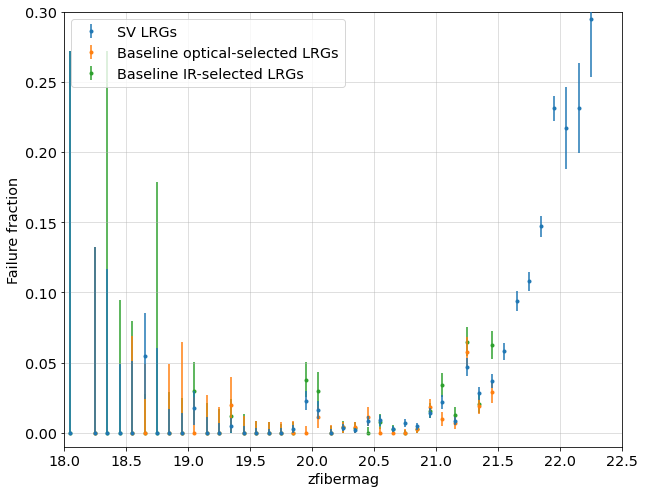

In [14]:
bin_centers = (bins[1:]+bins[:-1])/2

n_lrg_sv, _ = np.histogram(zbest['zfibermag'][lrg_sv], bins=bins)
n_lrg_sv_fail, _ = np.histogram(zbest['zfibermag'][lrg_sv & mask_fail], bins=bins)
n, p_lrg_sv = n_lrg_sv, n_lrg_sv_fail/n_lrg_sv
p1 = np.maximum(p_lrg_sv, 1/n)  # error floor
errors_sv = np.clip(np.sqrt(n * p_lrg_sv * (1-p_lrg_sv))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_opt, _ = np.histogram(zbest['zfibermag'][lrg_opt], bins=bins)
n_lrg_opt_fail, _ = np.histogram(zbest['zfibermag'][lrg_opt & mask_fail], bins=bins)
n, p_lrg_opt = n_lrg_opt, n_lrg_opt_fail/n_lrg_opt
p1 = np.maximum(p_lrg_opt, 1/n)  # error floor
errors_opt = np.clip(np.sqrt(n * p_lrg_opt * (1-p_lrg_opt))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_ir, _ = np.histogram(zbest['zfibermag'][lrg_ir], bins=bins)
n_lrg_ir_fail, _ = np.histogram(zbest['zfibermag'][lrg_ir & mask_fail], bins=bins)
n, p_lrg_ir = n_lrg_ir, n_lrg_ir_fail/n_lrg_ir
p1 = np.maximum(p_lrg_ir, 1/n)  # error floor
errors_ir = np.clip(np.sqrt(n * p_lrg_ir * (1-p_lrg_ir))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

plt.figure(figsize=(10, 8))
plt.errorbar(bin_centers, p_lrg_sv, yerr=(np.clip(errors_sv, None, p_lrg_sv), errors_sv),
             fmt='.', label='SV LRGs', zorder=3)
plt.errorbar(bin_centers, p_lrg_opt, yerr=(np.clip(errors_opt, None, p_lrg_opt), errors_opt),
             fmt='.', label='Baseline optical-selected LRGs', zorder=2)
plt.errorbar(bin_centers, p_lrg_ir, yerr=(np.clip(errors_ir, None, p_lrg_ir), errors_ir),
             fmt='.', label='Baseline IR-selected LRGs', zorder=1)
plt.xlabel('zfibermag')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.xlim(18, 22.5)
plt.ylim(-0.01, 0.3)
plt.legend(loc='upper left')
plt.show()

<ipython-input-15-aed8d88d2383>:5: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv = n_lrg_sv, n_lrg_sv_fail/n_lrg_sv
<ipython-input-15-aed8d88d2383>:6: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv, 1/n)  # error floor
<ipython-input-15-aed8d88d2383>:11: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_opt = n_lrg_opt, n_lrg_opt_fail/n_lrg_opt
<ipython-input-15-aed8d88d2383>:12: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_opt, 1/n)  # error floor
<ipython-input-15-aed8d88d2383>:17: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_ir = n_lrg_ir, n_lrg_ir_fail/n_lrg_ir
<ipython-input-15-aed8d88d2383>:18: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_ir, 1/n)  # error floor


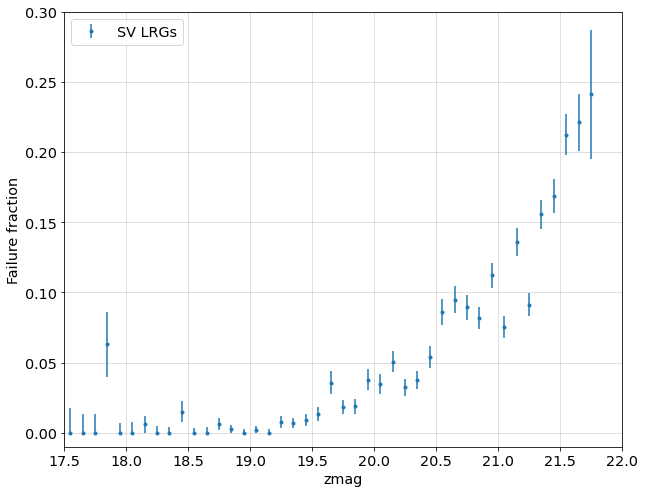

In [15]:
bin_centers = (bins[1:]+bins[:-1])/2

n_lrg_sv, _ = np.histogram(zbest['zmag'][lrg_sv], bins=bins)
n_lrg_sv_fail, _ = np.histogram(zbest['zmag'][lrg_sv & mask_fail], bins=bins)
n, p_lrg_sv = n_lrg_sv, n_lrg_sv_fail/n_lrg_sv
p1 = np.maximum(p_lrg_sv, 1/n)  # error floor
errors_sv = np.clip(np.sqrt(n * p_lrg_sv * (1-p_lrg_sv))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_opt, _ = np.histogram(zbest['zmag'][lrg_opt], bins=bins)
n_lrg_opt_fail, _ = np.histogram(zbest['zmag'][lrg_opt & mask_fail], bins=bins)
n, p_lrg_opt = n_lrg_opt, n_lrg_opt_fail/n_lrg_opt
p1 = np.maximum(p_lrg_opt, 1/n)  # error floor
errors_opt = np.clip(np.sqrt(n * p_lrg_opt * (1-p_lrg_opt))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_ir, _ = np.histogram(zbest['zmag'][lrg_ir], bins=bins)
n_lrg_ir_fail, _ = np.histogram(zbest['zmag'][lrg_ir & mask_fail], bins=bins)
n, p_lrg_ir = n_lrg_ir, n_lrg_ir_fail/n_lrg_ir
p1 = np.maximum(p_lrg_ir, 1/n)  # error floor
errors_ir = np.clip(np.sqrt(n * p_lrg_ir * (1-p_lrg_ir))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

plt.figure(figsize=(10, 8))
plt.errorbar(bin_centers, p_lrg_sv, yerr=(np.clip(errors_sv, None, p_lrg_sv), errors_sv),
             fmt='.', label='SV LRGs', zorder=3)
# plt.errorbar(bin_centers, p_lrg_opt, yerr=(np.clip(errors_opt, None, p_lrg_opt), errors_opt),
#              fmt='.', label='Baseline optical-selected LRGs', zorder=2)
# plt.errorbar(bin_centers, p_lrg_ir, yerr=(np.clip(errors_ir, None, p_lrg_ir), errors_ir),
#              fmt='.', label='Baseline IR-selected LRGs', zorder=1)
plt.xlabel('zmag')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.xlim(17.5, 22)
plt.ylim(-0.01, 0.3)
plt.legend(loc='upper left')
plt.show()

--------

[18.  18.5 19.  19.5 20.  20.5 21.  21.5 22.  22.5]
[0.  0.2 0.4 0.6 0.8 1.  1.2]


<ipython-input-16-9fcd1ac868fa>:10: RuntimeWarning: invalid value encountered in true_divide
  plt.imshow(hist_fail/hist_all, aspect='auto', extent=(z_bins.min(), z_bins.max(), zfiber_bins.min(), zfiber_bins.max()), origin='lower', vmax=0.2, cmap='jet')


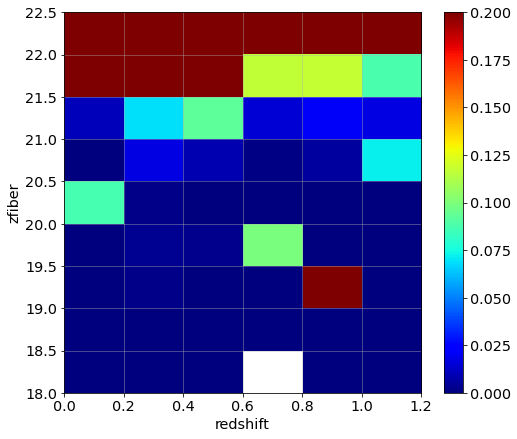

In [16]:
# 2-D failure rates
zfiber_bins = np.linspace(18., 22.5, 10)
z_bins = np.linspace(0., 1.2, 7)
print(zfiber_bins)
print(z_bins)
hist_all, _, _ = np.histogram2d(zbest['zfibermag'][mask_zwarn], zbest['Z_deep'][mask_zwarn], bins=[zfiber_bins, z_bins])
hist_fail, _, _ = np.histogram2d(zbest['zfibermag'][mask_fail], zbest['Z_deep'][mask_fail], bins=[zfiber_bins, z_bins])

plt.figure(figsize=(8, 7))
plt.imshow(hist_fail/hist_all, aspect='auto', extent=(z_bins.min(), z_bins.max(), zfiber_bins.min(), zfiber_bins.max()), origin='lower', vmax=0.2, cmap='jet')
plt.colorbar()
plt.xlabel('redshift')
plt.ylabel('zfiber')
plt.grid(alpha=0.5)
plt.show()

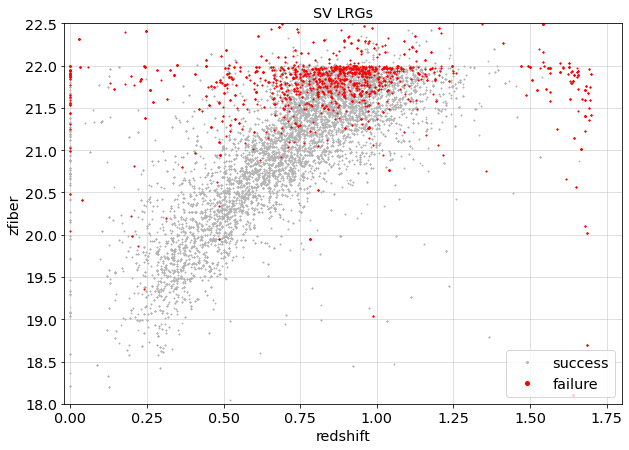

In [17]:
plt.figure(figsize=(10, 7))
plt.plot(zbest['Z_deep'][mask_zwarn & lrg_sv & (~mask_fail)], zbest['zfibermag'][mask_zwarn & lrg_sv & (~mask_fail)], '.', ms=1, color='0.7', label='success')
plt.plot(zbest['Z_deep'][mask_fail & lrg_sv], zbest['zfibermag'][mask_fail & lrg_sv], '.', ms=2, color='r', label='failure')
plt.axis([-0.02, 1.8, 18, 22.5])
plt.xlabel('redshift')
plt.ylabel('zfiber')
plt.grid(alpha=0.5)
plt.legend(loc='lower right')
plt.legend(loc='lower right', markerscale=4)
plt.title('SV LRGs')
plt.show()

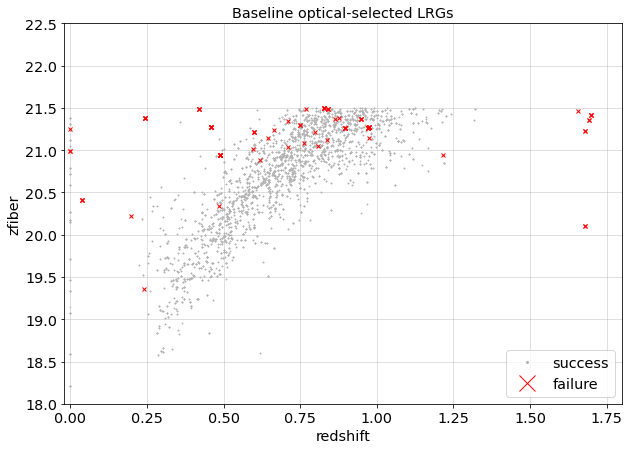

In [18]:
plt.figure(figsize=(10, 7))
plt.plot(zbest['Z_deep'][mask_zwarn & lrg_opt & (~mask_fail)], zbest['zfibermag'][mask_zwarn & lrg_opt & (~mask_fail)], '.', ms=1, color='0.7', label='success')
plt.plot(zbest['Z_deep'][mask_fail & lrg_opt], zbest['zfibermag'][mask_fail & lrg_opt], 'x', ms=4, color='r', label='failure')
plt.axis([-0.02, 1.8, 18, 22.5])
plt.xlabel('redshift')
plt.ylabel('zfiber')
plt.grid(alpha=0.5)
plt.legend(loc='lower right', markerscale=4)
plt.title('Baseline optical-selected LRGs')
plt.show()

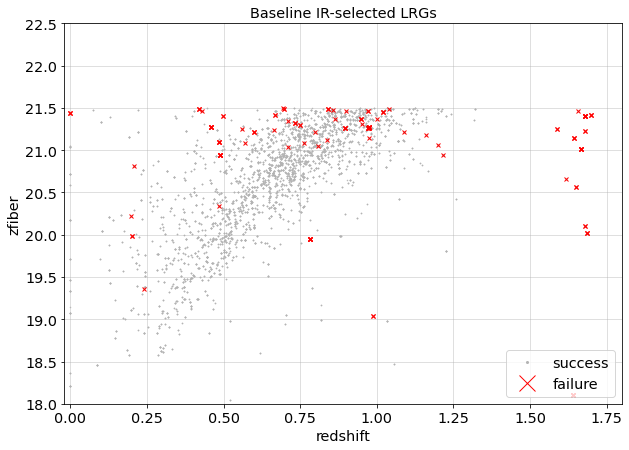

In [19]:
plt.figure(figsize=(10, 7))
plt.plot(zbest['Z_deep'][mask_zwarn & lrg_ir & (~mask_fail)], zbest['zfibermag'][mask_zwarn & lrg_ir & (~mask_fail)], '.', ms=1, color='0.7', label='success')
plt.plot(zbest['Z_deep'][mask_fail & lrg_ir], zbest['zfibermag'][mask_fail & lrg_ir], 'x', ms=4, color='r', label='failure')
plt.axis([-0.02, 1.8, 18, 22.5])
plt.xlabel('redshift')
plt.ylabel('zfiber')
plt.grid(alpha=0.5)
plt.legend(loc='lower right', markerscale=4)
plt.title('Baseline IR-selected LRGs')
plt.show()